# 💳 Credit Card Fraud Detection

## Objective
Build a machine learning model to detect fraudulent credit card transactions.

### Dataset
- Source: Kaggle - Credit Card Fraud Detection (ULB)
- Total Transactions: 284,807
- Fraud Transactions: 492 (0.17%)
- Features: V1-V28 (PCA transformed), Amount, Time

## 📚 Importing Libraries
Importing all necessary libraries for data manipulation, visualization, machine learning and explainability.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

## 📂 Loading Dataset
Loading the credit card transaction dataset and taking a first look at the data.

In [3]:
df=pd.read_csv('creditcard.csv',encoding='latin-1')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 🧹 Data Cleaning
- Checking for duplicate values
- Checking for missing values
- Checking data types

In [7]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df[df.duplicated() == True]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [9]:
df.duplicated().sum()

np.int64(1081)

In [10]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [12]:
df=df.reset_index(drop=True)

In [13]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.shape

(283726, 31)

## 📊 Exploratory Data Analysis
Analyzing the distribution of fraud vs normal transactions and understanding key patterns in the data.

In [15]:
print(df['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


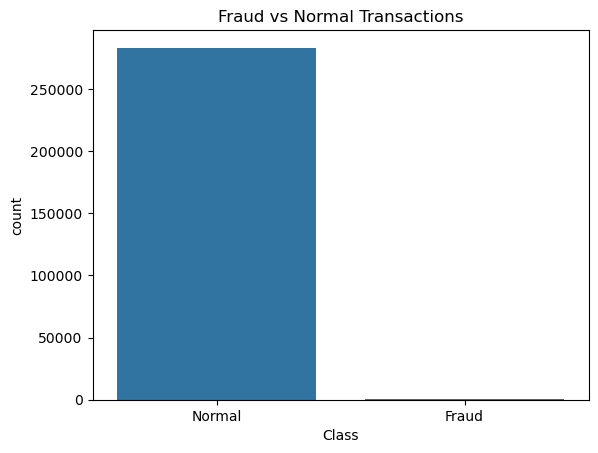

In [17]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

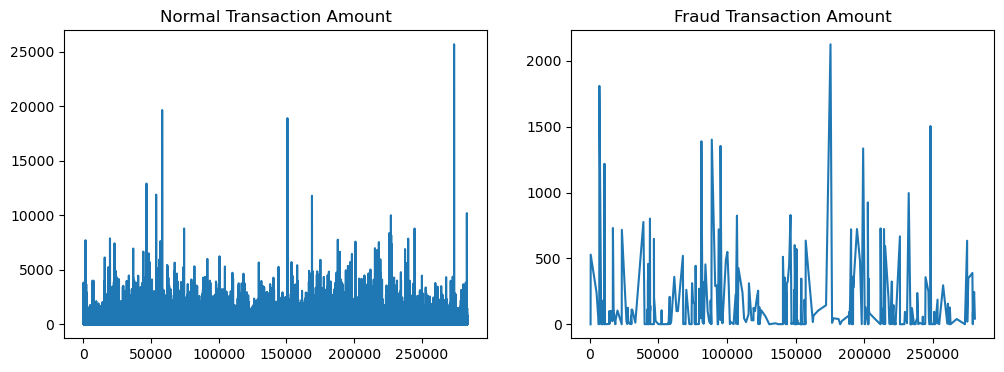

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
df[df['Class']==0]['Amount'].plot(ax=ax1, title="Normal Transaction Amount")
df[df['Class']==1]['Amount'].plot(ax=ax2, title="Fraud Transaction Amount")
plt.show()

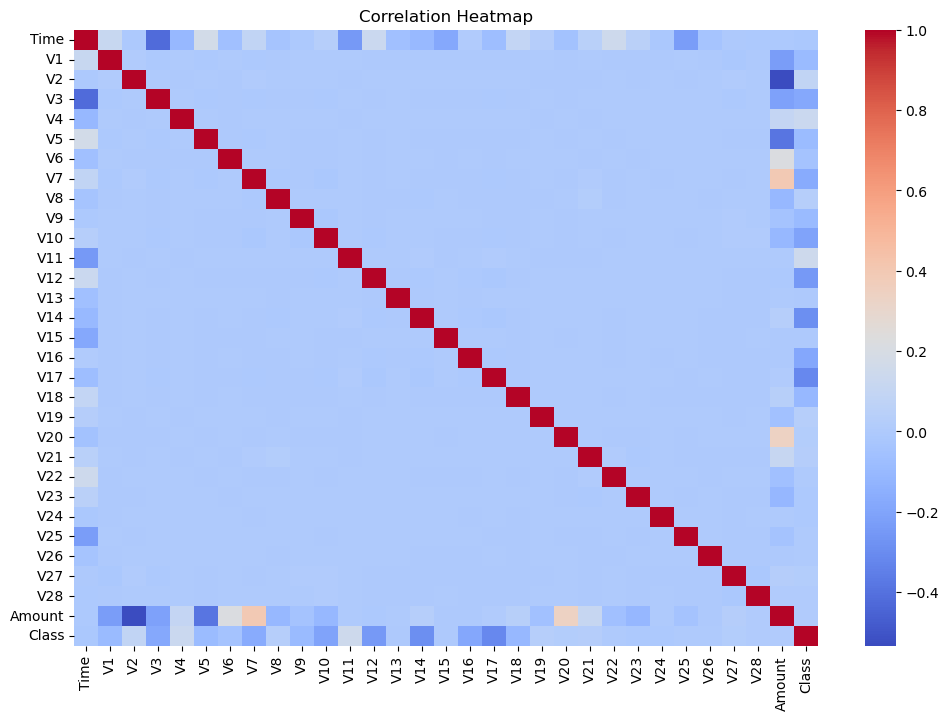

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## ⚙️ Feature Scaling
Applying StandardScaler to Amount and Time columns since V1-V28 are already PCA transformed.

In [15]:
Scaler=StandardScaler()

In [16]:
df['Time']=Scaler.fit_transform(df[['Time']])
df['Amount']=Scaler.fit_transform(df[['Amount']])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [17]:
df.shape

(283726, 31)

In [18]:
print(df['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


## ✂️ Train Test Split
Splitting the dataset into training (80%) and testing (20%) sets.

In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

In [20]:
X.shape

(283726, 30)

In [21]:
y.shape

(283726,)

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## ⚖️ Handling Class Imbalance using SMOTE
The dataset is highly imbalanced with only 0.17% fraud transactions.
Applying SMOTE (Synthetic Minority Oversampling Technique) only on training data to balance the classes.

In [23]:
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [24]:
print(X_train_smote.value_counts().sum())

453194


In [25]:
print(y_train_smote.value_counts().sum())

453194


## 🤖 Model 1 - Logistic Regression
Training Logistic Regression as our baseline model.

In [26]:
log=LogisticRegression()
log.fit(X_train_smote,y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
y_pred=log.predict(X_test)

In [28]:
print(y_pred)

[0 0 0 ... 0 0 0]


In [29]:
log.score(X_test,y_test)

0.9752229232016354

### 📈 Logistic Regression Evaluation
Evaluating using Classification Report, Confusion Matrix and ROC-AUC Score.

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.05      0.89      0.10        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.54     56746
weighted avg       1.00      0.98      0.99     56746



In [31]:
print(confusion_matrix(y_test,y_pred))

[[55260  1396]
 [   10    80]]


In [32]:
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

ROC-AUC: 0.9321244783331764


## 🌲 Model 2 - Random Forest
Training Random Forest Classifier with hyperparameters.

In [33]:
rfc= RandomForestClassifier(
    n_estimators=100,        
    criterion='entropy',
    min_samples_split=10,
    max_depth=14,
    random_state=42,
    n_jobs=-1           
)

In [34]:
rfc.fit(X_train_smote,y_train_smote)

,n_estimators,100
,criterion,'entropy'
,max_depth,14
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred2=rfc.predict(X_test)

In [36]:
print(y_pred)

[0 0 0 ... 0 0 0]


In [37]:
print(rfc.score(X_test,y_test))

0.9993303492757198


### 📈 Random Forest Evaluation

In [38]:
print(confusion_matrix(y_test,y_pred2))

[[56638    18]
 [   20    70]]


In [39]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.80      0.78      0.79        90

    accuracy                           1.00     56746
   macro avg       0.90      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [40]:
print(roc_auc_score(y_test,y_pred2))

0.8887300354576547


## 🌳 Model 3 - Decision Tree
Training Decision Tree Classifier.

In [41]:
dt=DecisionTreeClassifier(random_state=42)

In [42]:
dt.fit(X_train_smote,y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred3=dt.predict(X_test)

In [44]:
print(y_pred3)

[0 0 0 ... 0 0 0]


In [45]:
print(dt.score(X_test,y_test))

0.9977267120149438


### 📈 Decision Tree Evaluation

In [46]:
print(confusion_matrix(y_test,y_pred3))

[[56550   106]
 [   23    67]]


In [47]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.39      0.74      0.51        90

    accuracy                           1.00     56746
   macro avg       0.69      0.87      0.75     56746
weighted avg       1.00      1.00      1.00     56746



In [48]:
print(roc_auc_score(y_test,y_pred3))

0.8712867520160658


## 📉 ROC Curve Comparison
Comparing all 3 models using ROC Curve to visualize their performance.
- Higher the curve = better the model
- Logistic Regression (0.98) clearly outperforms others
- Decision Tree performed the worst with 0.87 AUC

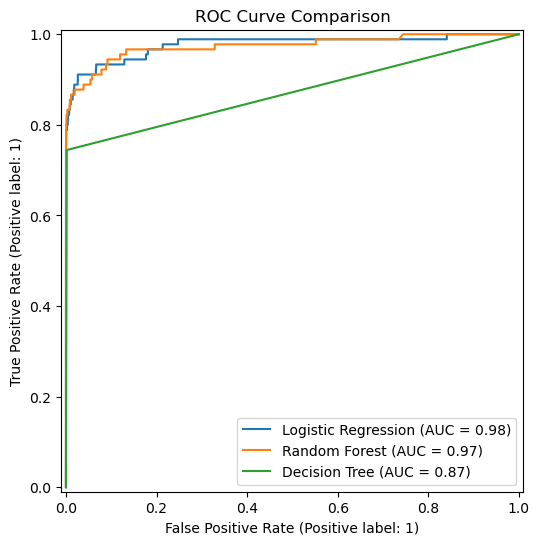

In [49]:
fig, ax = plt.subplots(figsize=(8,6))
RocCurveDisplay.from_estimator(log, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rfc, X_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(dt, X_test, y_test, ax=ax, name="Decision Tree")
plt.title("ROC Curve Comparison")
plt.show()

## 🔍 SHAP Explainability
Using SHAP (SHapley Additive exPlanations) to explain model predictions and identify the most important features driving fraud detection.

In [50]:
explainer=shap.LinearExplainer(log,X_train_smote)
shap_values = explainer.shap_values(X_test)

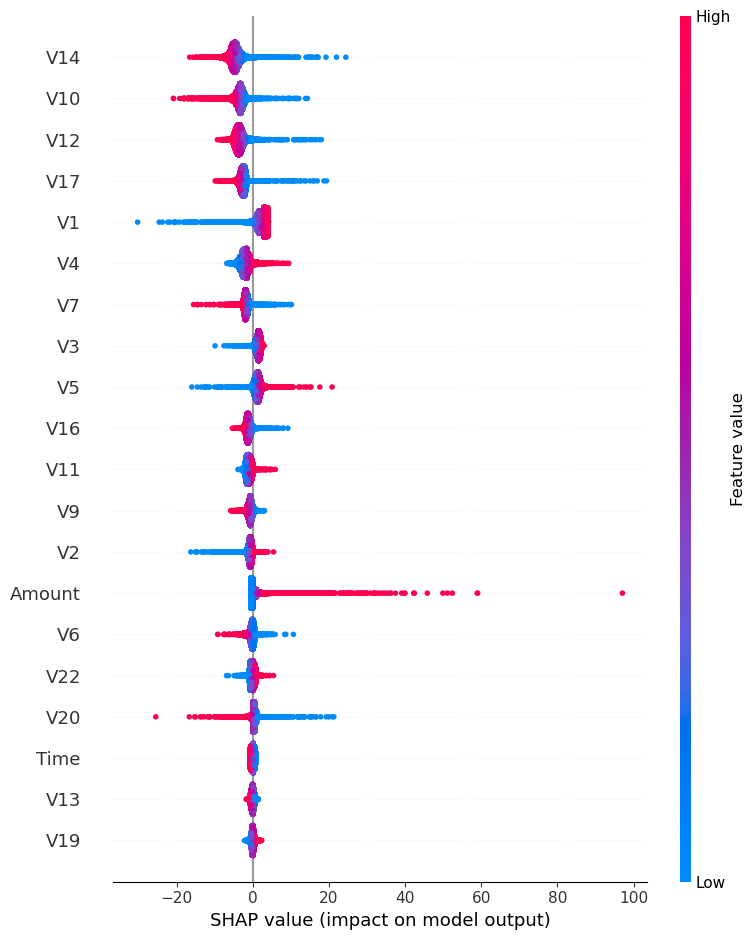

In [51]:
shap.summary_plot(shap_values, X_test)

In [52]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

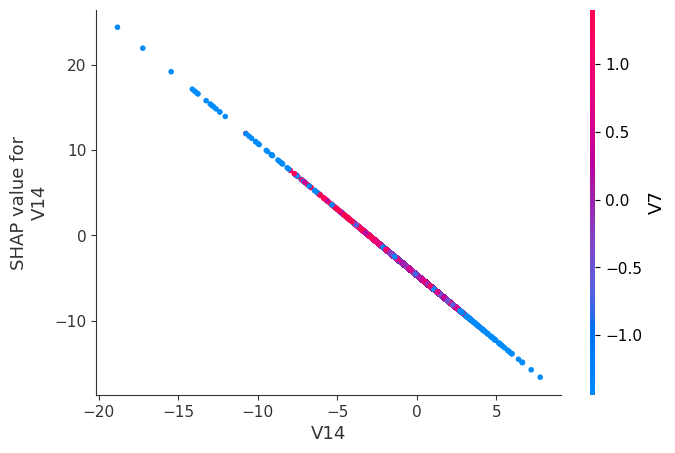

In [53]:
shap.dependence_plot("V14", shap_values, X_test)

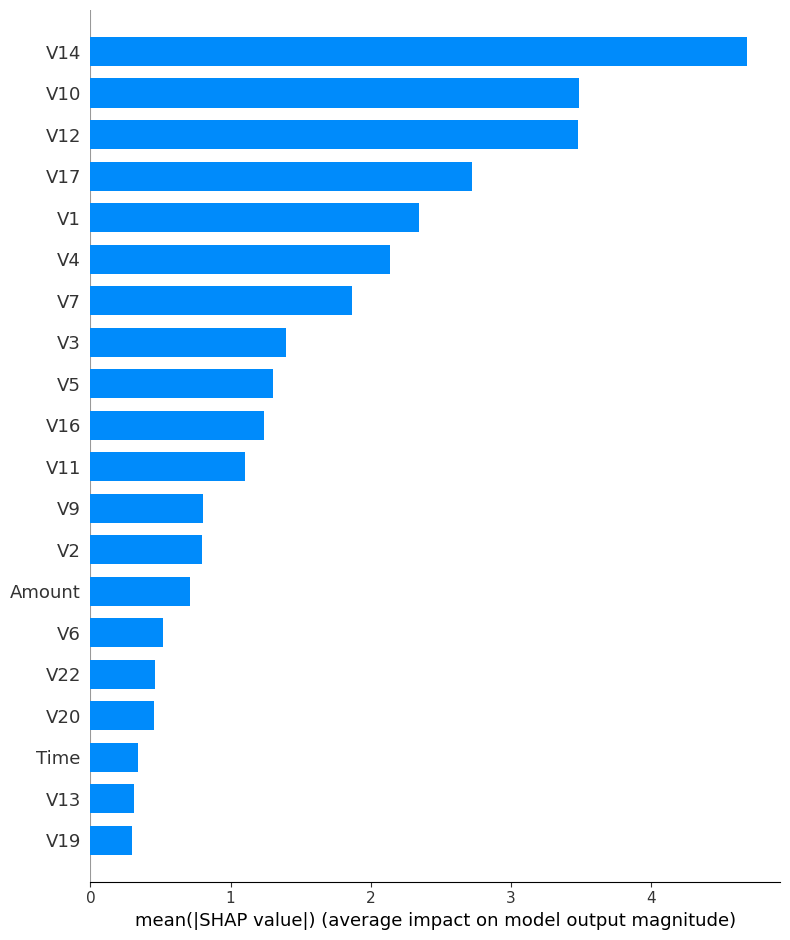

In [54]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## 💾 Saving the Model
Saving the best performing model (Logistic Regression) as a pickle file
for deployment in the Streamlit web application.

In [55]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(log, f)

## ✅ Conclusion

### Key Findings:
- Dataset had severe class imbalance — only 0.17% fraud transactions
- SMOTE successfully balanced the training data
- Logistic Regression achieved the best ROC-AUC of 0.98
- V14 was the strongest fraud indicator according to SHAP analysis
- Low values of V14 strongly indicate fraudulent transactions

### Model Comparison:
| Model | ROC-AUC |
|---|---|
| Logistic Regression | 0.98 🏆 |
| Random Forest | 0.97 |
| Decision Tree | 0.87 |